In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Save Model
import joblib

In [3]:
df=pd.read_csv("email_spam_detection.csv") 

In [4]:
df.head()

,Email_ID,Sender_Email,Subject,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
0,1,,Meeting,NaN,99,-1,7,0,0
1,2,user1@outlook.com,Security Alert,87.0,2,3,8,0,0
2,3,user2@yahoo.com,Win Prize,69.0,0,3,8,0,0
3,4,user3@gmail.com,Invoice,61.0,0,3,8,0,0
4,5,user4@company.com,Meeting,99.0,2,3,5,0,0


In [5]:
df.columns

Index(['Email_ID', 'Sender_Email', 'Subject', 'Email_Length', 'Num_Links',
       'Num_Special_Chars', 'Capital_Words', 'Has_Attachment', 'Spam'],
      dtype='str')

In [6]:
df.shape

(7000, 9)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Email_ID           7000 non-null   int64  
 1   Sender_Email       6999 non-null   str    
 2   Subject            7000 non-null   str    
 3   Email_Length       6959 non-null   float64
 4   Num_Links          7000 non-null   int64  
 5   Num_Special_Chars  7000 non-null   int64  
 6   Capital_Words      7000 non-null   int64  
 7   Has_Attachment     7000 non-null   int64  
 8   Spam               7000 non-null   int64  
dtypes: float64(1), int64(6), str(2)
memory usage: 694.4 KB


In [8]:
df.describe()

,Email_ID,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
count,7000.000000,6959.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,3500.500000,110.567898,2.454571,6.636429,12.199714,0.260714,0.305143
std,2020.870275,52.353566,5.319235,6.123388,15.169749,0.439056,0.460501
min,1.000000,20.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,1750.750000,70.000000,0.000000,2.000000,3.000000,0.000000,0.000000
50%,3500.500000,95.000000,1.000000,4.000000,6.000000,0.000000,0.000000
75%,5250.250000,158.000000,3.000000,11.000000,10.250000,1.000000,1.000000
max,7000.000000,265.000000,99.000000,28.000000,59.000000,1.000000,1.000000


In [9]:
df.isnull().sum()

Email_ID              0
Sender_Email          1
Subject               0
Email_Length         41
Num_Links             0
Num_Special_Chars     0
Capital_Words         0
Has_Attachment        0
Spam                  0
dtype: int64

In [10]:
(df.isnull().sum()/len(df))*100

Email_ID             0.000000
Sender_Email         0.014286
Subject              0.000000
Email_Length         0.585714
Num_Links            0.000000
Num_Special_Chars    0.000000
Capital_Words        0.000000
Has_Attachment       0.000000
Spam                 0.000000
dtype: float64

In [11]:
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

,Email_ID,Sender_Email,Subject,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
0,1,NaN,Meeting,NaN,99,-1,7,0,0
1,2,user1@outlook.com,Security Alert,87.0,2,3,8,0,0
2,3,user2@yahoo.com,Win Prize,69.0,0,3,8,0,0
3,4,user3@gmail.com,Invoice,61.0,0,3,8,0,0
4,5,user4@company.com,Meeting,99.0,2,3,5,0,0
...,...,...,...,...,...,...,...,...,...
6995,6996,user6995@gmail.com,Greetings,93.0,1,2,6,1,0
6996,6997,user6996@yahoo.com,Offer,107.0,0,0,7,0,0
6997,6998,user6997@gmail.com,Account Verification,222.0,7,14,17,0,1
6998,6999,user6998@outlook.com,Win Prize,164.0,6,16,8,1,1


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.dtypes

Email_ID               int64
Sender_Email             str
Subject                  str
Email_Length         float64
Num_Links              int64
Num_Special_Chars      int64
Capital_Words          int64
Has_Attachment         int64
Spam                   int64
dtype: object

In [15]:
df["Email_Length"] = pd.to_numeric(#errors="coerce" converts invalid values to NaN so they can be handled later.
    df["Email_Length"],
    errors="coerce"
)

In [16]:
df["Num_Special_Chars"] = df["Num_Special_Chars"].replace(-1, np.nan)

In [17]:
df["Num_Special_Chars"] = df["Num_Special_Chars"].fillna(df["Num_Special_Chars"].median())#Median is less affected by outliers than the mean.

In [18]:
df["Num_Links"]=df["Num_Links"].replace(99,np.nan)

In [19]:
df["Num_Links"]=df["Num_Links"].fillna(df["Num_Links"].median())

In [20]:
df.head()

,Email_ID,Sender_Email,Subject,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
0,1,NaN,Meeting,NaN,1.0,4.0,7,0,0
1,2,user1@outlook.com,Security Alert,87.0,2.0,3.0,8,0,0
2,3,user2@yahoo.com,Win Prize,69.0,0.0,3.0,8,0,0
3,4,user3@gmail.com,Invoice,61.0,0.0,3.0,8,0,0
4,5,user4@company.com,Meeting,99.0,2.0,3.0,5,0,0


In [21]:
df.drop("Sender_Email", axis=1, inplace=True)

In [22]:
df.head()

,Email_ID,Subject,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
0,1,Meeting,NaN,1.0,4.0,7,0,0
1,2,Security Alert,87.0,2.0,3.0,8,0,0
2,3,Win Prize,69.0,0.0,3.0,8,0,0
3,4,Invoice,61.0,0.0,3.0,8,0,0
4,5,Meeting,99.0,2.0,3.0,5,0,0


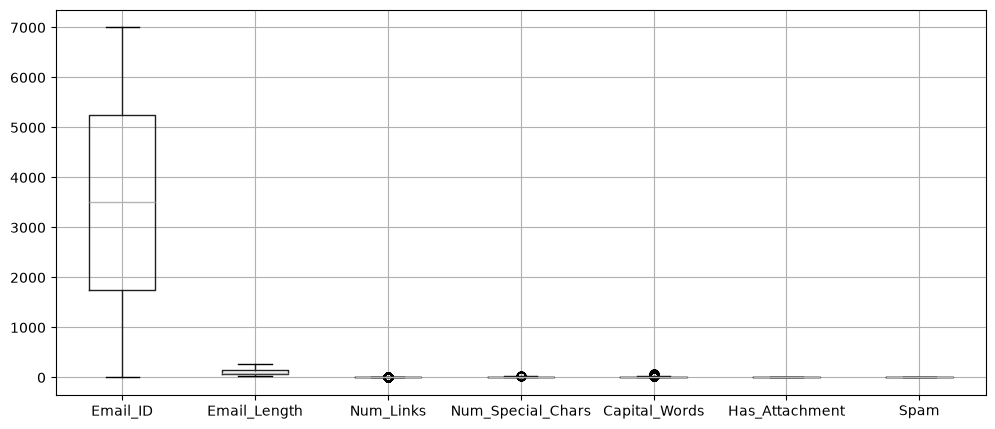

In [23]:
import matplotlib.pyplot as plt
df.boxplot(figsize=(12,5))
plt.show()

In [24]:
numeric_df = df.select_dtypes(include=['number'])

In [25]:
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1 

In [26]:
outliers = ((numeric_df < (Q1 - 1.5 * IQR)) |
            (numeric_df > (Q3 + 1.5 * IQR))).sum()

print(outliers)

Email_ID                0
Email_Length            0
Num_Links             283
Num_Special_Chars      26
Capital_Words        1349
Has_Attachment          0
Spam                    0
dtype: int64


In [27]:
outlier_rows = numeric_df[
    ((numeric_df < (Q1 - 1.5 * IQR)) |
     (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)#Agar Outlier Rows dekhna chahte ho
]

outlier_rows.head()

,Email_ID,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
7,8,221.0,8.0,17.0,43,1,1
8,9,154.0,7.0,9.0,38,0,1
10,11,192.0,8.0,12.0,51,0,1
18,19,186.0,7.0,16.0,24,1,1
23,24,198.0,4.0,12.0,25,1,1


In [28]:
df = df[~((numeric_df < (Q1 - 1.5 * IQR)) |(numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [29]:
df.head()

,Email_ID,Subject,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
0,1,Meeting,NaN,1.0,4.0,7,0,0
1,2,Security Alert,87.0,2.0,3.0,8,0,0
2,3,Win Prize,69.0,0.0,3.0,8,0,0
3,4,Invoice,61.0,0.0,3.0,8,0,0
4,5,Meeting,99.0,2.0,3.0,5,0,0


In [30]:
df.drop(["Email_ID", "Subject"], axis=1, inplace=True)

In [31]:
df.head()

,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
0,NaN,1.0,4.0,7,0,0
1,87.0,2.0,3.0,8,0,0
2,69.0,0.0,3.0,8,0,0
3,61.0,0.0,3.0,8,0,0
4,99.0,2.0,3.0,5,0,0


In [32]:
df.isnull().sum()

Email_Length         33
Num_Links             0
Num_Special_Chars     0
Capital_Words         0
Has_Attachment        0
Spam                  0
dtype: int64

In [33]:
df["Email_Length"] = df["Email_Length"].fillna(df["Email_Length"].median())

In [34]:
df.isnull().sum()

Email_Length         0
Num_Links            0
Num_Special_Chars    0
Capital_Words        0
Has_Attachment       0
Spam                 0
dtype: int64

In [35]:
df.head()

,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
0,84.0,1.0,4.0,7,0,0
1,87.0,2.0,3.0,8,0,0
2,69.0,0.0,3.0,8,0,0
3,61.0,0.0,3.0,8,0,0
4,99.0,2.0,3.0,5,0,0


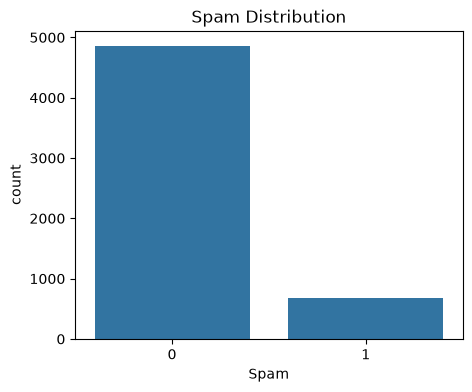

In [36]:
plt.figure(figsize=(5,4))
sns.countplot(x="Spam", data=df)
plt.title("Spam Distribution")
plt.show()

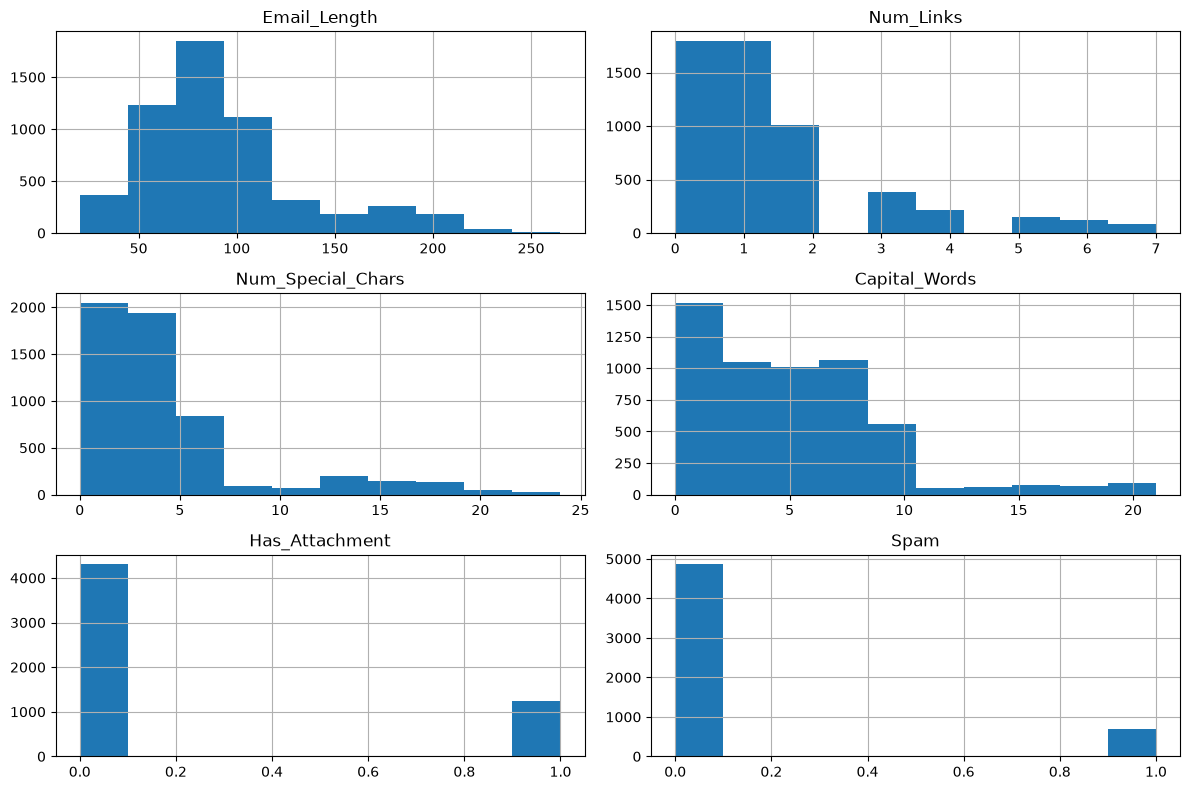

In [37]:
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

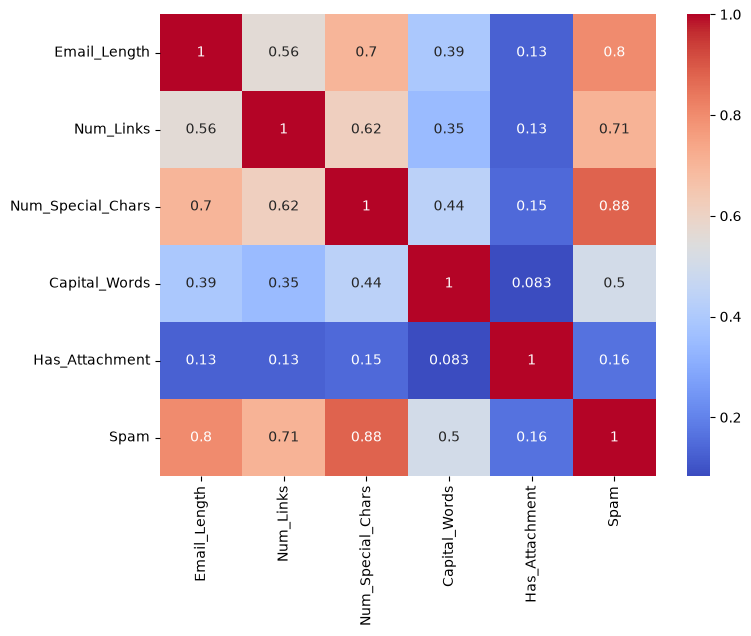

In [38]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()


In [39]:
df["Spam"].unique()

array([0, 1])

In [40]:
encoder = LabelEncoder()
df["Spam"] = encoder.fit_transform(df["Spam"])

In [41]:
X = df.drop("Spam", axis=1)
y = df["Spam"]

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [43]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [44]:
nb = GaussianNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

In [45]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [46]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [47]:
models = {
    "Logistic Regression": lr_pred,
    "Naive Bayes": nb_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred
}

for name, pred in models.items():
    print("="*40)
    print(name)
    print("Accuracy:", accuracy_score(y_test, pred))
    print(classification_report(y_test, pred))

Logistic Regression
Accuracy: 0.9981981981981982
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       973
           1       0.99      1.00      0.99       137

    accuracy                           1.00      1110
   macro avg       0.99      1.00      1.00      1110
weighted avg       1.00      1.00      1.00      1110

Naive Bayes
Accuracy: 0.9981981981981982
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       973
           1       0.99      0.99      0.99       137

    accuracy                           1.00      1110
   macro avg       1.00      1.00      1.00      1110
weighted avg       1.00      1.00      1.00      1110

Decision Tree
Accuracy: 0.9972972972972973
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       973
           1       0.99      0.99      0.99       137

    accuracy                           1.00      

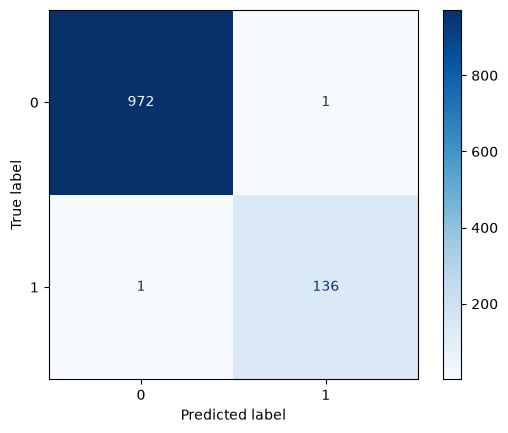

In [48]:
ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    cmap="Blues"
)

plt.show()

In [49]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

             Feature  Importance
2  Num_Special_Chars    0.455808
0       Email_Length    0.333088
1          Num_Links    0.119991
3      Capital_Words    0.090278
4     Has_Attachment    0.000835


In [50]:
joblib.dump(rf, "spam_model.pkl")

['spam_model.pkl']

In [51]:
sample = [[250,2,15,8,1]]

prediction = rf.predict(sample)

print(prediction)

[1]
